In [3]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pprint 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

df = pd.read_csv("/Users/zl23295/Library/CloudStorage/Box-Box/371M ML/MechineLearning_FinalProject/alzheimers_disease_data.csv")
df = df.drop(columns=["PatientID","DoctorInCharge"], errors="ignore")

df.head()
types = df.dtypes
print(types)


Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
BehavioralProblems             int64
ADL                          float64
C

In [4]:
px.pie(df, names='Diagnosis', color='Diagnosis',
       color_discrete_sequence=['#007500','#5CFF5C'],
       title='Data Distribution')

Descriptive statistics:
                                 mean          sd         min         max
Age                         74.908795    8.990221   60.000000   90.000000
Gender                       0.506282    0.500077    0.000000    1.000000
Ethnicity                    0.697534    0.996128    0.000000    3.000000
EducationLevel               1.286645    0.904527    0.000000    3.000000
BMI                         27.655697    7.217438   15.008851   39.992767
Smoking                      0.288506    0.453173    0.000000    1.000000
AlcoholConsumption          10.039442    5.757910    0.002003   19.989293
PhysicalActivity             4.920202    2.857191    0.003616    9.987429
DietQuality                  4.993138    2.909055    0.009385    9.998346
SleepQuality                 7.051081    1.763573    4.002629    9.999840
FamilyHistoryAlzheimers      0.252210    0.434382    0.000000    1.000000
CardiovascularDisease        0.144253    0.351428    0.000000    1.000000
Diabetes      

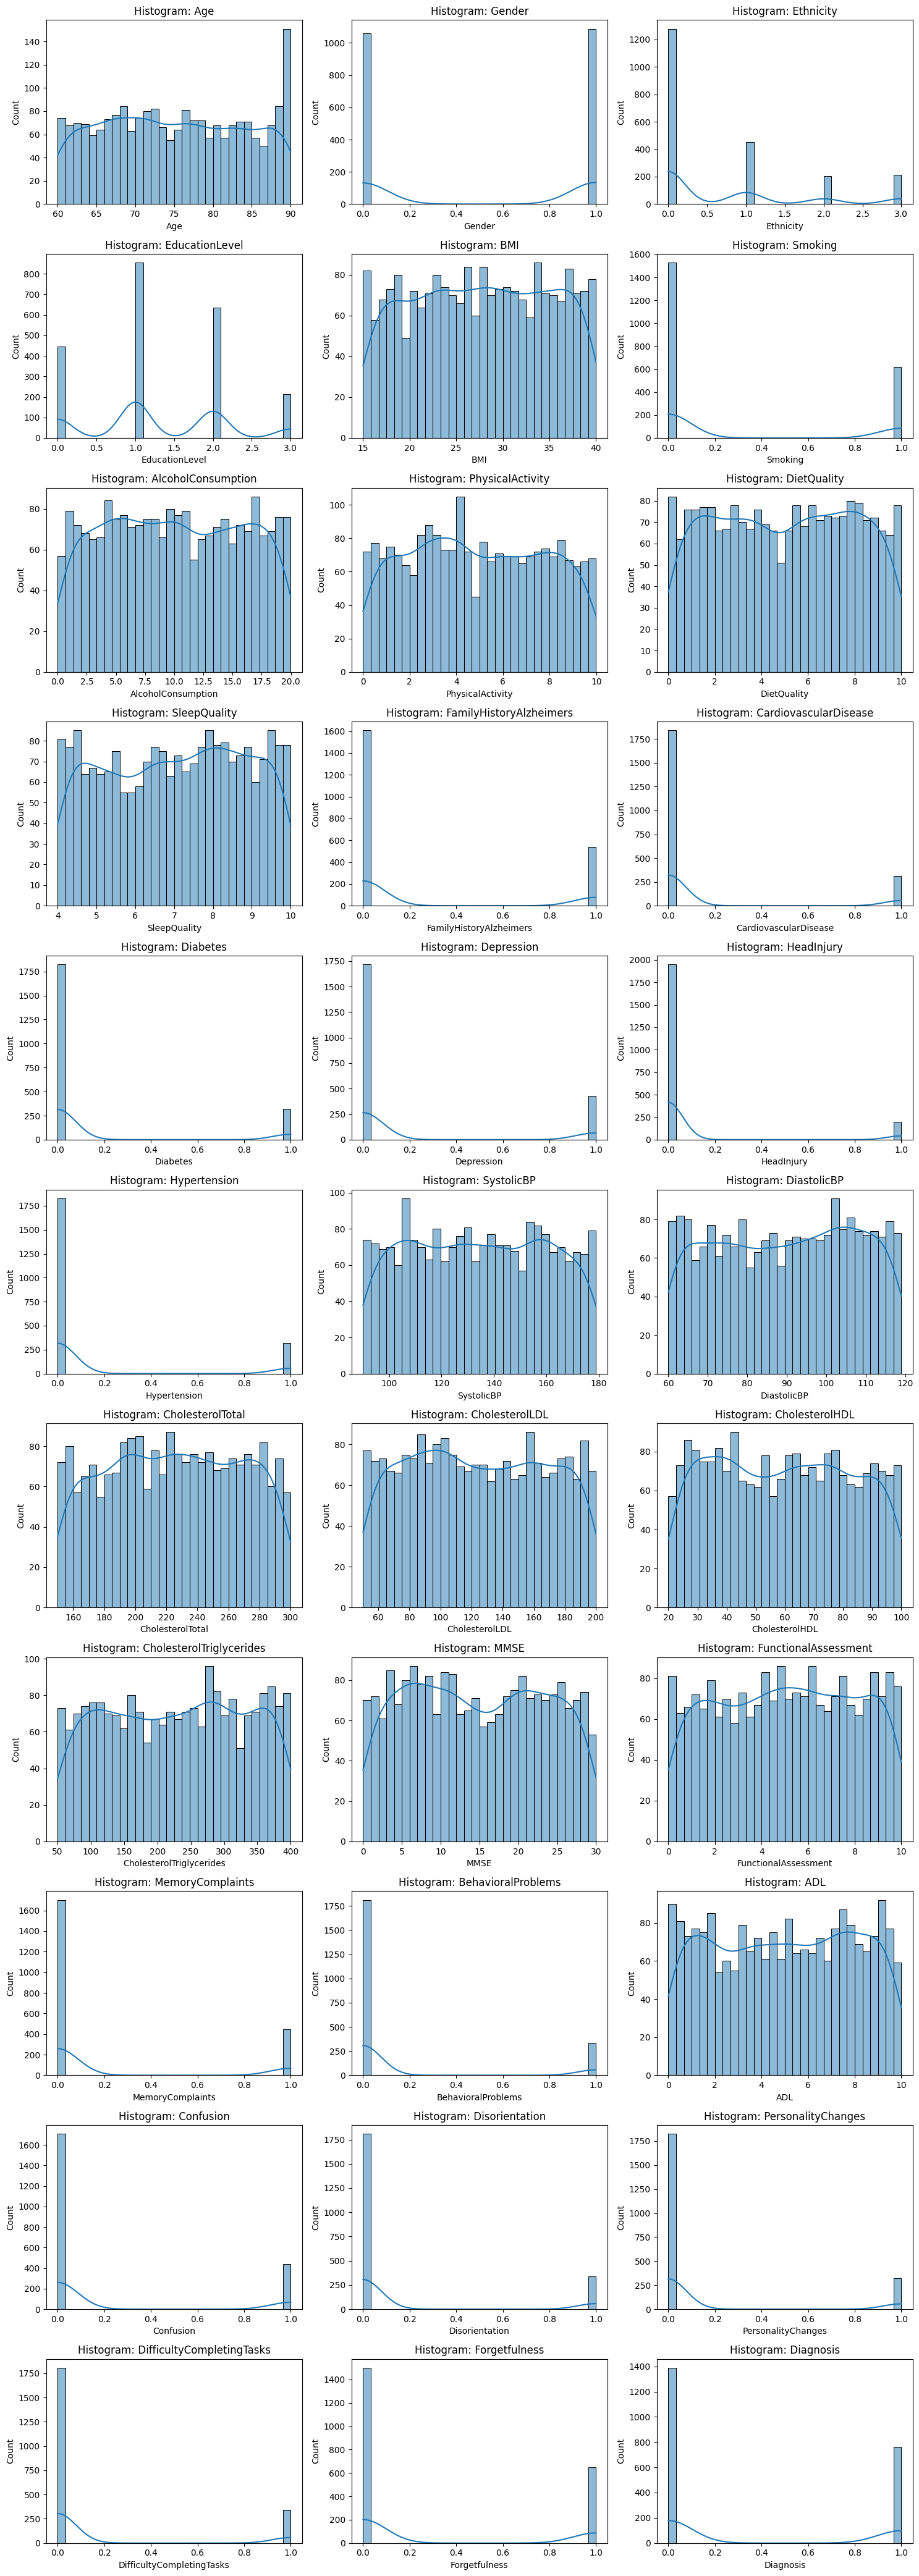

In [5]:
# Understanding the data distribution
properties = df.select_dtypes(include=[np.number]).columns.tolist()
desc = (
df[properties]
.agg(["mean", "std", "min", "max"])
.T
.rename(columns={"std": "sd"})
)
print("Descriptive statistics:")
print(desc)

n = len(properties)
ncols = 3
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(5 * ncols, 3.8 * nrows))
for i, col in enumerate(properties, 1):
    ax = plt.subplot(nrows, ncols, i)
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax)
    ax.set_title(f"Histogram: {col}")
plt.tight_layout()
plt.show()

In [7]:
outlier_rows = []
outlier_mask_all = pd.Series(False, index=df.index)

for col in properties:
    s = df[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    outlier_mask_all = outlier_mask_all | mask.fillna(False)
    
    outlier_rows.append({
        "property": col,
        "outlier_count": int(mask.sum()),
        "outlier_pct": round(mask.mean() * 100, 2),
        "lower_bound": lower,
        "upper_bound": upper
    })
outlier_df = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)

print("\nOutlier summary (IQR rule):")
print(outlier_df)


Outlier summary (IQR rule):
                     property  outlier_count  outlier_pct  lower_bound  \
24           MemoryComplaints            447        20.80     0.000000   
27                  Confusion            441        20.52     0.000000   
13                 Depression            431        20.06     0.000000   
30  DifficultyCompletingTasks            341        15.87     0.000000   
28             Disorientation            340        15.82     0.000000   
25         BehavioralProblems            337        15.68     0.000000   
29         PersonalityChanges            324        15.08     0.000000   
12                   Diabetes            324        15.08     0.000000   
15               Hypertension            320        14.89     0.000000   
11      CardiovascularDisease            310        14.43     0.000000   
2                   Ethnicity            211         9.82    -1.500000   
14                 HeadInjury            199         9.26     0.000000   
22       

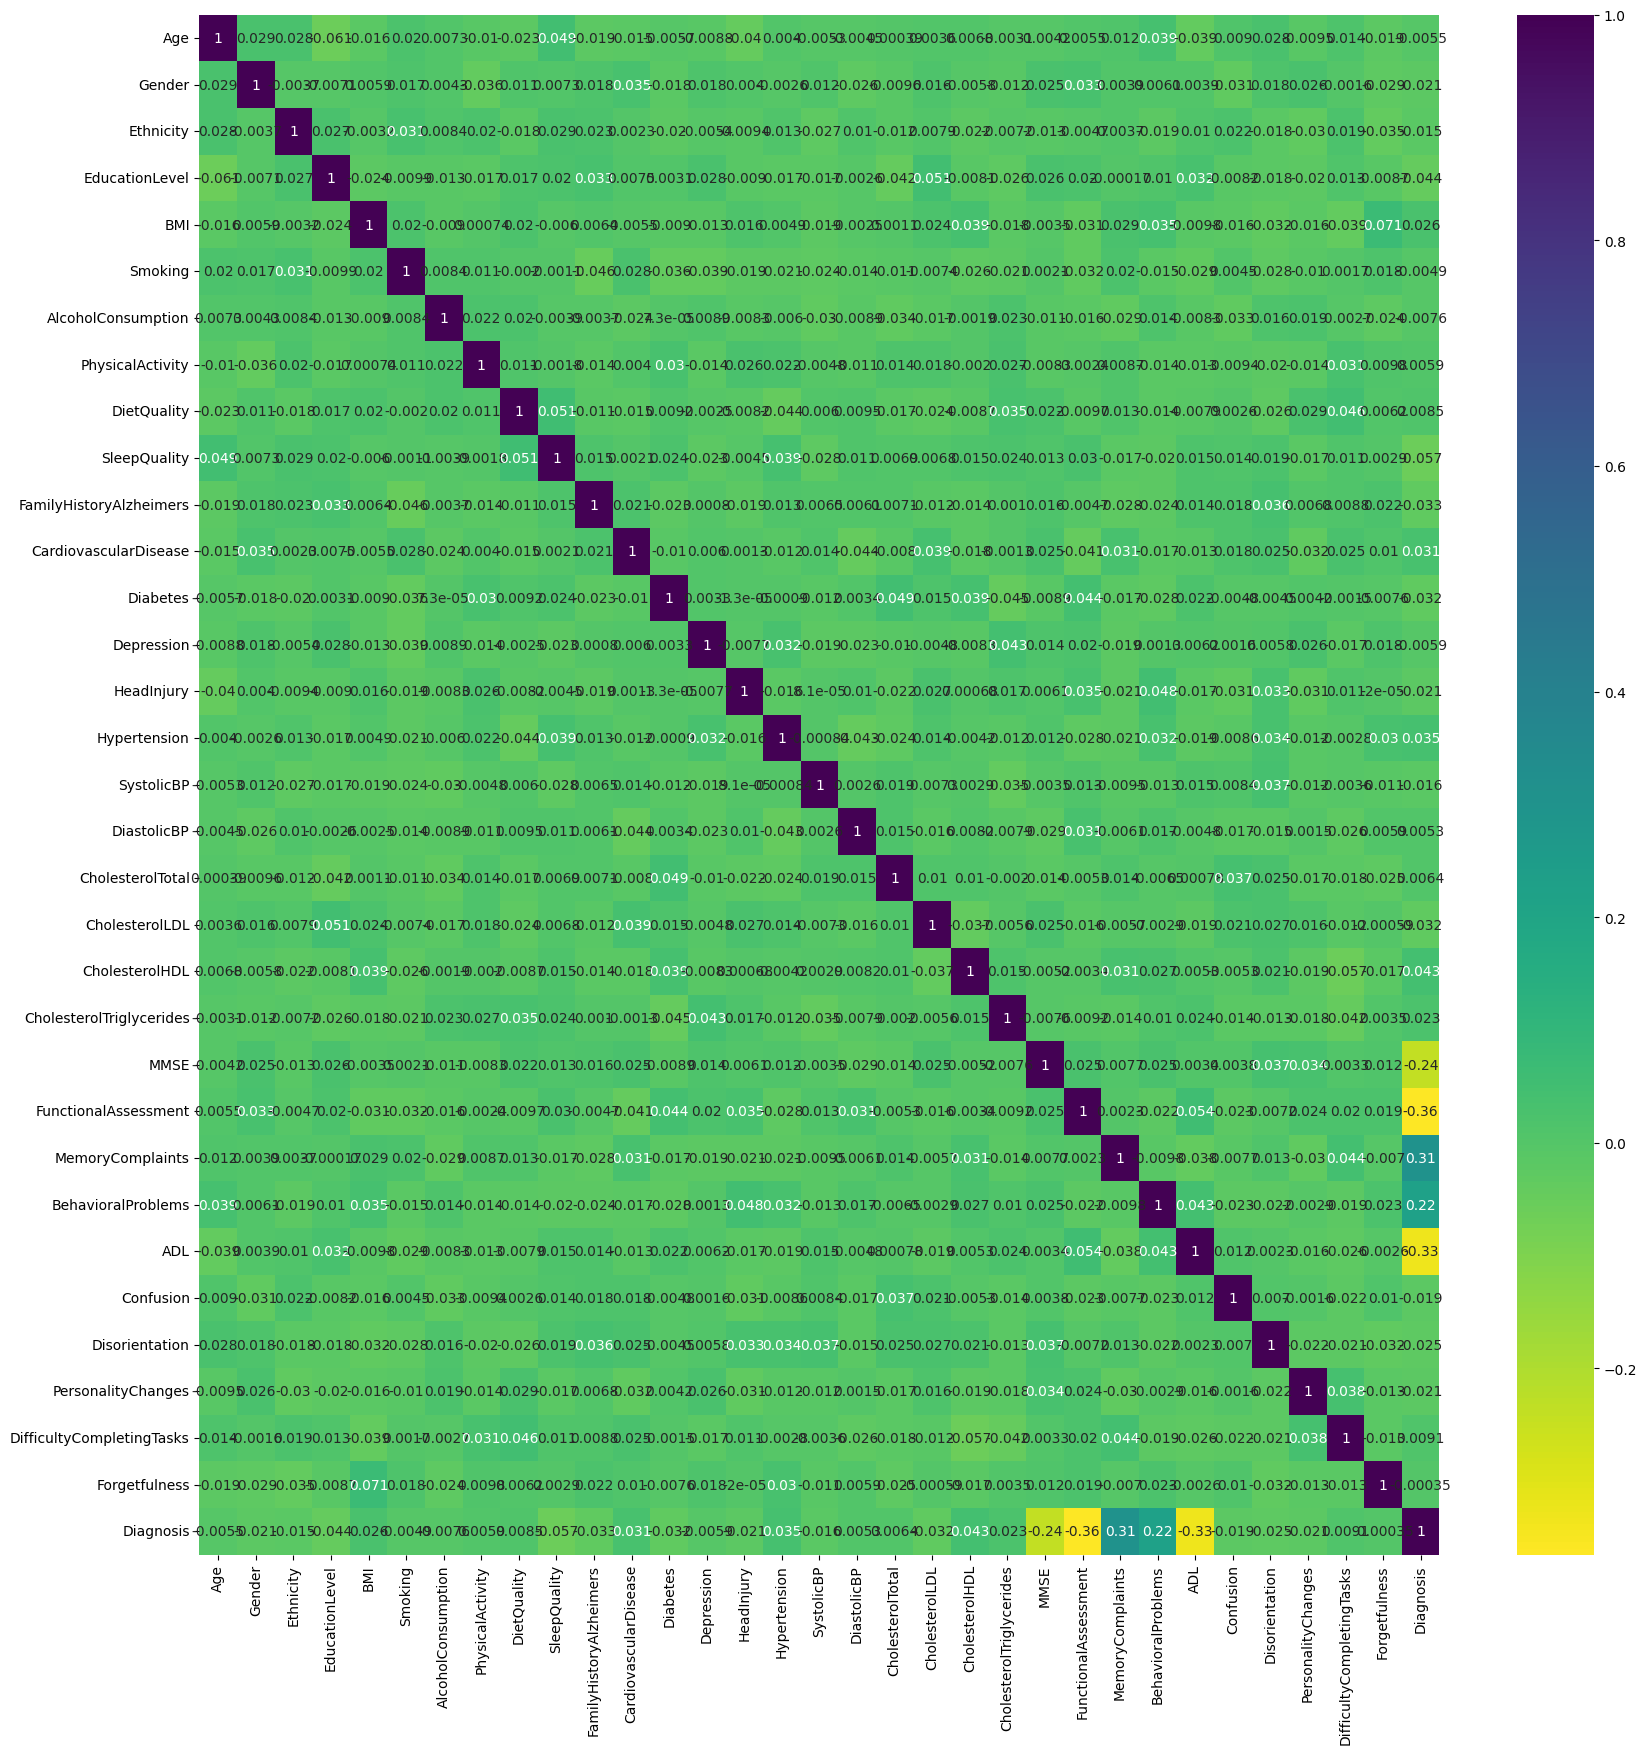

In [ ]:
corr = df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='viridis_r',annot=True)
plt.show()


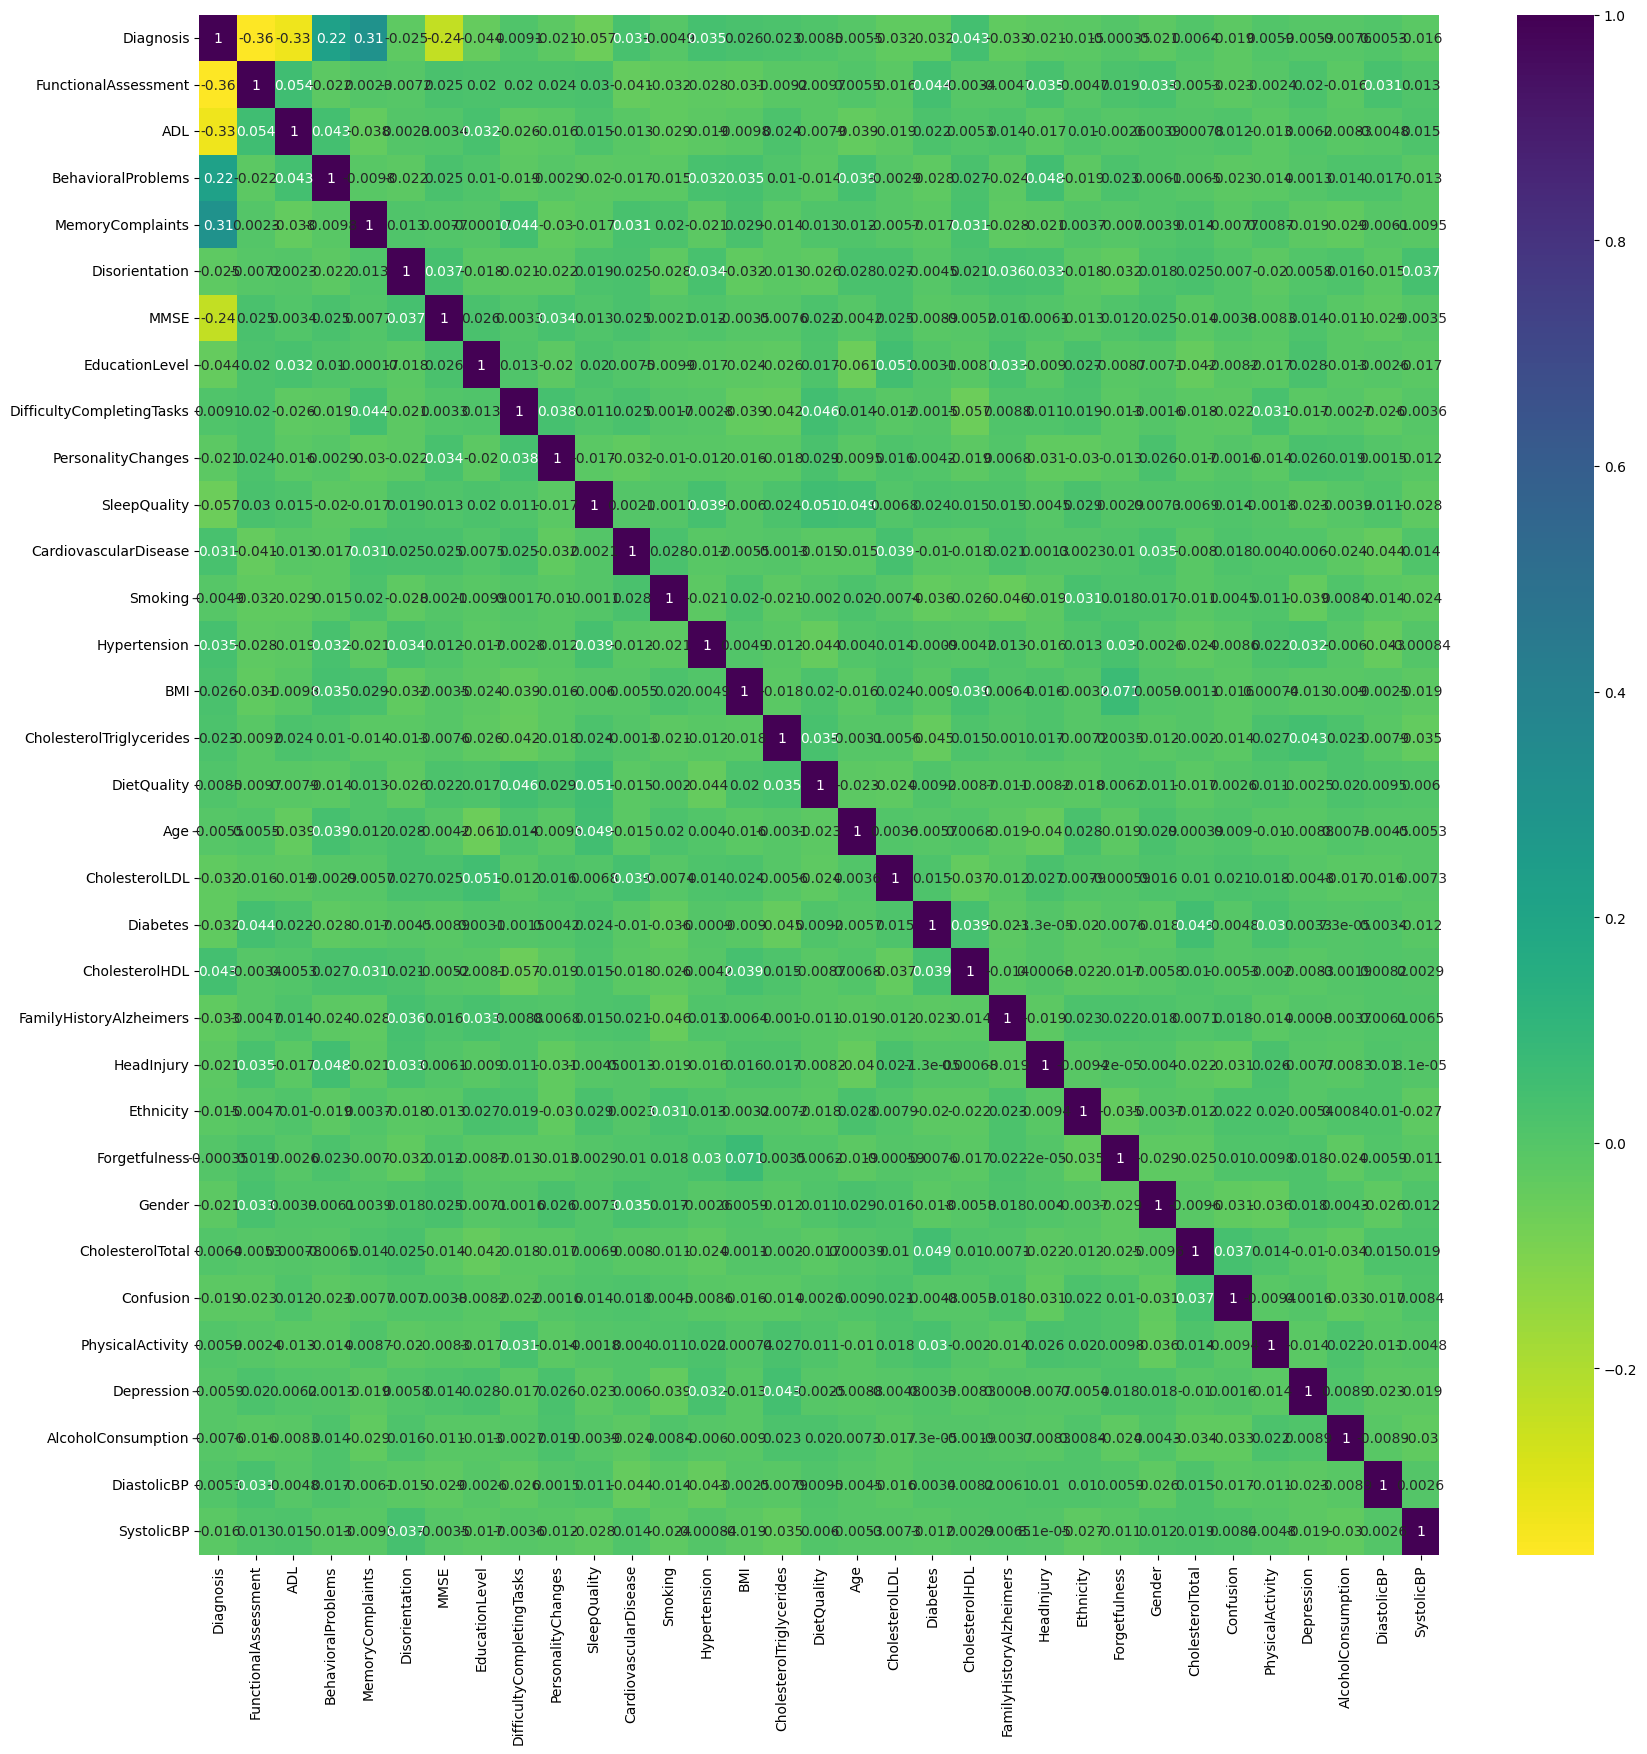

MemoryComplaints             0.306742
BehavioralProblems           0.224350
CholesterolHDL               0.042584
Hypertension                 0.035080
CardiovascularDisease        0.031490
BMI                          0.026343
CholesterolTriglycerides     0.022672
DifficultyCompletingTasks    0.009069
DietQuality                  0.008506
CholesterolTotal             0.006394
PhysicalActivity             0.005945
DiastolicBP                  0.005293
Forgetfulness               -0.000354
Smoking                     -0.004865
Age                         -0.005488
Depression                  -0.005893
AlcoholConsumption          -0.007618
Ethnicity                   -0.014782
SystolicBP                  -0.015615
Confusion                   -0.019186
PersonalityChanges          -0.020627
Gender                      -0.020975
HeadInjury                  -0.021411
Disorientation              -0.024648
Diabetes                    -0.031508
CholesterolLDL              -0.031976
FamilyHistor

In [ ]:
# Order features by overall absolute correlation strength
corr = df.corr().abs()
sorted_features = corr.sum().sort_values(ascending=False).index
corr_sorted = df[sorted_features].corr().loc[sorted_features, sorted_features]

plt.figure(figsize=(20, 20))
sns.heatmap(corr_sorted, cmap='viridis_r', annot=True)
plt.show()



In [ ]:
# Correlation of each variable with Diagnosis, sorted from highest to lowest
diagnosis_corr = df.corr(numeric_only=True)['Diagnosis'].drop('Diagnosis').sort_values(ascending=False)
print(diagnosis_corr)
diagnosis_corr.to_csv('diagnosis_corr.csv', header=['correlation'])

# Ethnicity's correlation value is meaningless Because it's not ordinal data


MemoryComplaints             0.306742
BehavioralProblems           0.224350
CholesterolHDL               0.042584
Hypertension                 0.035080
CardiovascularDisease        0.031490
BMI                          0.026343
CholesterolTriglycerides     0.022672
DifficultyCompletingTasks    0.009069
DietQuality                  0.008506
CholesterolTotal             0.006394
PhysicalActivity             0.005945
DiastolicBP                  0.005293
Forgetfulness               -0.000354
Smoking                     -0.004865
Age                         -0.005488
Depression                  -0.005893
AlcoholConsumption          -0.007618
Ethnicity                   -0.014782
SystolicBP                  -0.015615
Confusion                   -0.019186
PersonalityChanges          -0.020627
Gender                      -0.020975
HeadInjury                  -0.021411
Disorientation              -0.024648
Diabetes                    -0.031508
CholesterolLDL              -0.031976
FamilyHistor

In [ ]:
# Remove 10 variables that are believed to closely related to the diagnosis 
# According to the correlation values, there are 6 variables have very high correlation with the diagnosis
# So we need to discuss if we want to keep/throw the other 4 
df_remove = df.drop(columns=['MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 
                             'Confusion', 'Disorientation','PersonalityChanges',
                             'DifficultyCompletingTasks','Forgetfulness'], errors='ignore')


Train: (1504, 22), Test: (645, 22)
Train class dist:
Diagnosis
0    0.646
1    0.354
Name: proportion, dtype: float64
depth=2  AUC=0.468
depth=3  AUC=0.472
depth=4  AUC=0.477
depth=5  AUC=0.496
depth=8  AUC=0.491
depth=None  AUC=0.500

Classification Report:
              precision    recall  f1-score   support

     Healthy      0.633     0.417     0.503       417
 Alzheimer's      0.343     0.557     0.425       228

    accuracy                          0.467       645
   macro avg      0.488     0.487     0.464       645
weighted avg      0.530     0.467     0.475       645

ROC-AUC: 0.494

Detailed Metrics Table:
              precision  recall  f1-score  support
Healthy           0.633   0.417     0.503  417.000
Alzheimer's       0.343   0.557     0.425  228.000
accuracy          0.467   0.467     0.467    0.467
macro avg         0.488   0.487     0.464  645.000
weighted avg      0.530   0.467     0.475  645.000


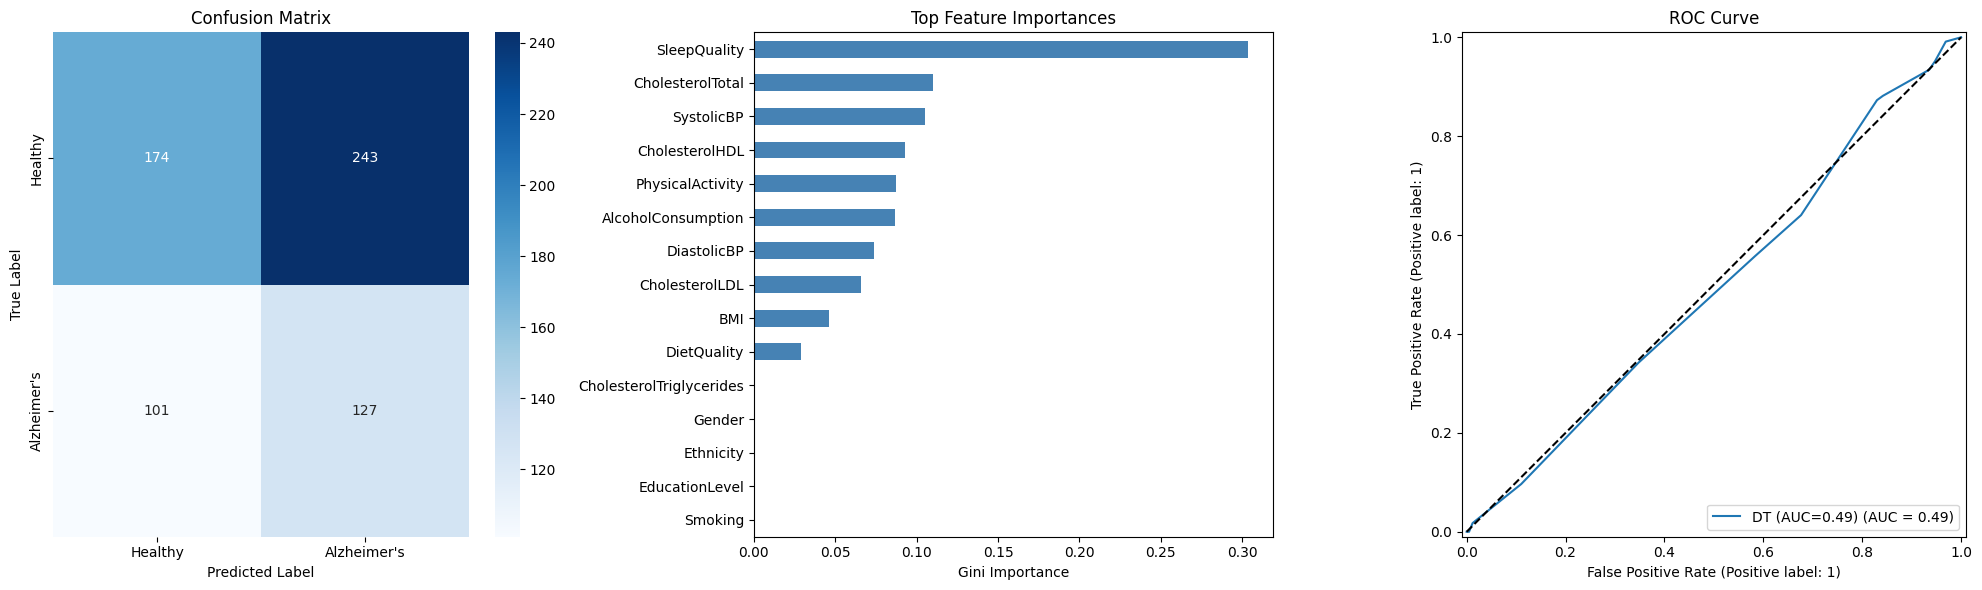

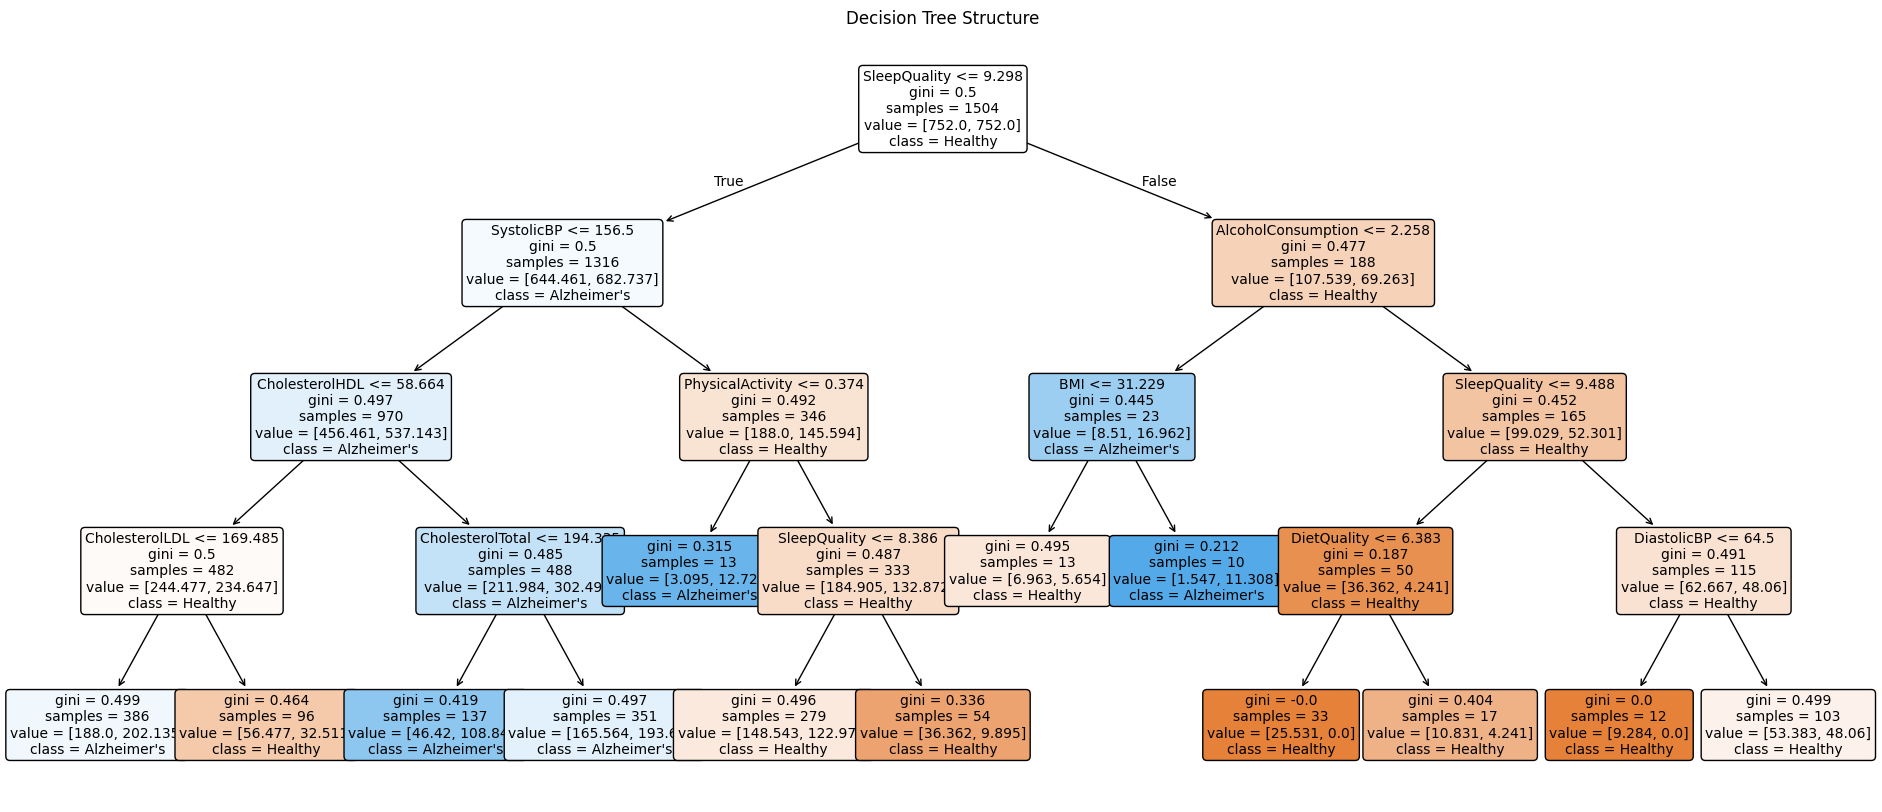

In [28]:

X = df_remove.drop(columns=["Diagnosis"])
y = df_remove["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y          # preserves 66/33 class ratio in both sets
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class dist:\n{y_train.value_counts(normalize=True).round(3)}")
# -- Step 5: Find best depth first
for depth in [2, 3, 4, 5, 8, None]:
    dt_temp = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=42)
    dt_temp.fit(X_train, y_train)
    y_proba_temp = dt_temp.predict_proba(X_test)[:, 1]
    print(f"depth={depth}  AUC={roc_auc_score(y_test, y_proba_temp):.3f}")

# -- Step 5b: Train final model with best depth
# After running above, replace max_depth with whichever gave highest AUC
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,            # change this to best depth from loop above
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train, y_train)

# -- Step 6: Evaluate
y_pred  = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Healthy", "Alzheimer's"], digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

# Detailed metric table: Precision, Recall, F1-score, Support
report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        target_names=["Healthy", "Alzheimer's"],
        output_dict=True,
        zero_division=0
    )
).transpose()

print("\nDetailed Metrics Table:")
print(report_df[["precision", "recall", "f1-score", "support"]].round(3))

# -- Step 7: Visualize
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# -- Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Healthy", "Alzheimer's"],
            yticklabels=["Healthy", "Alzheimer's"])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

# -- Feature Importances
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).tail(15).plot(
    kind="barh", ax=axes[1], color="steelblue"
)
axes[1].set_title("Top Feature Importances")
axes[1].set_xlabel("Gini Importance")

# -- ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[2],
                                  name=f"DT (AUC={roc_auc_score(y_test, y_proba):.2f})")
axes[2].set_title("ROC Curve")
axes[2].plot([0,1],[0,1],"k--")

plt.tight_layout()
plt.savefig("dt_evaluation.png", dpi=150)
plt.show()

# -- Tree Structure (separate figure - can get large)
plt.figure(figsize=(24, 10))
plot_tree(dt, feature_names=X.columns, class_names=["Healthy","Alzheimer's"],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure")
plt.savefig("dt_structure.png", dpi=150, bbox_inches="tight")
plt.show()


Train: (1504, 27), Test: (645, 27)
Train class dist:
Diagnosis
0    0.646
1    0.354
Name: proportion, dtype: float64
depth=2  AUC=0.468
depth=3  AUC=0.472
depth=4  AUC=0.477
depth=5  AUC=0.498
depth=8  AUC=0.487
depth=None  AUC=0.506

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.63      0.42      0.50       417
 Alzheimer's       0.34      0.56      0.42       228

    accuracy                           0.47       645
   macro avg       0.49      0.49      0.46       645
weighted avg       0.53      0.47      0.48       645

ROC-AUC: 0.494


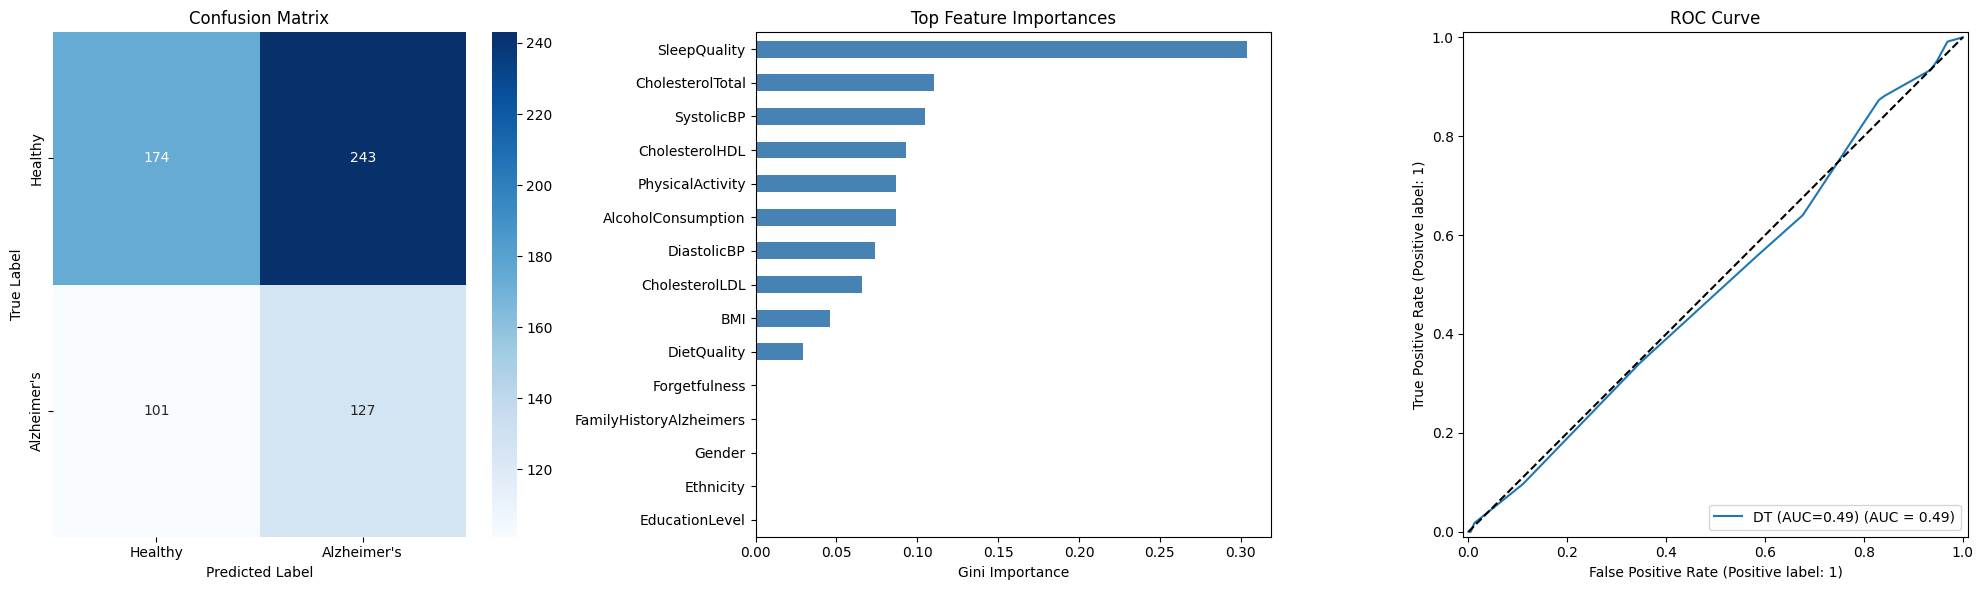

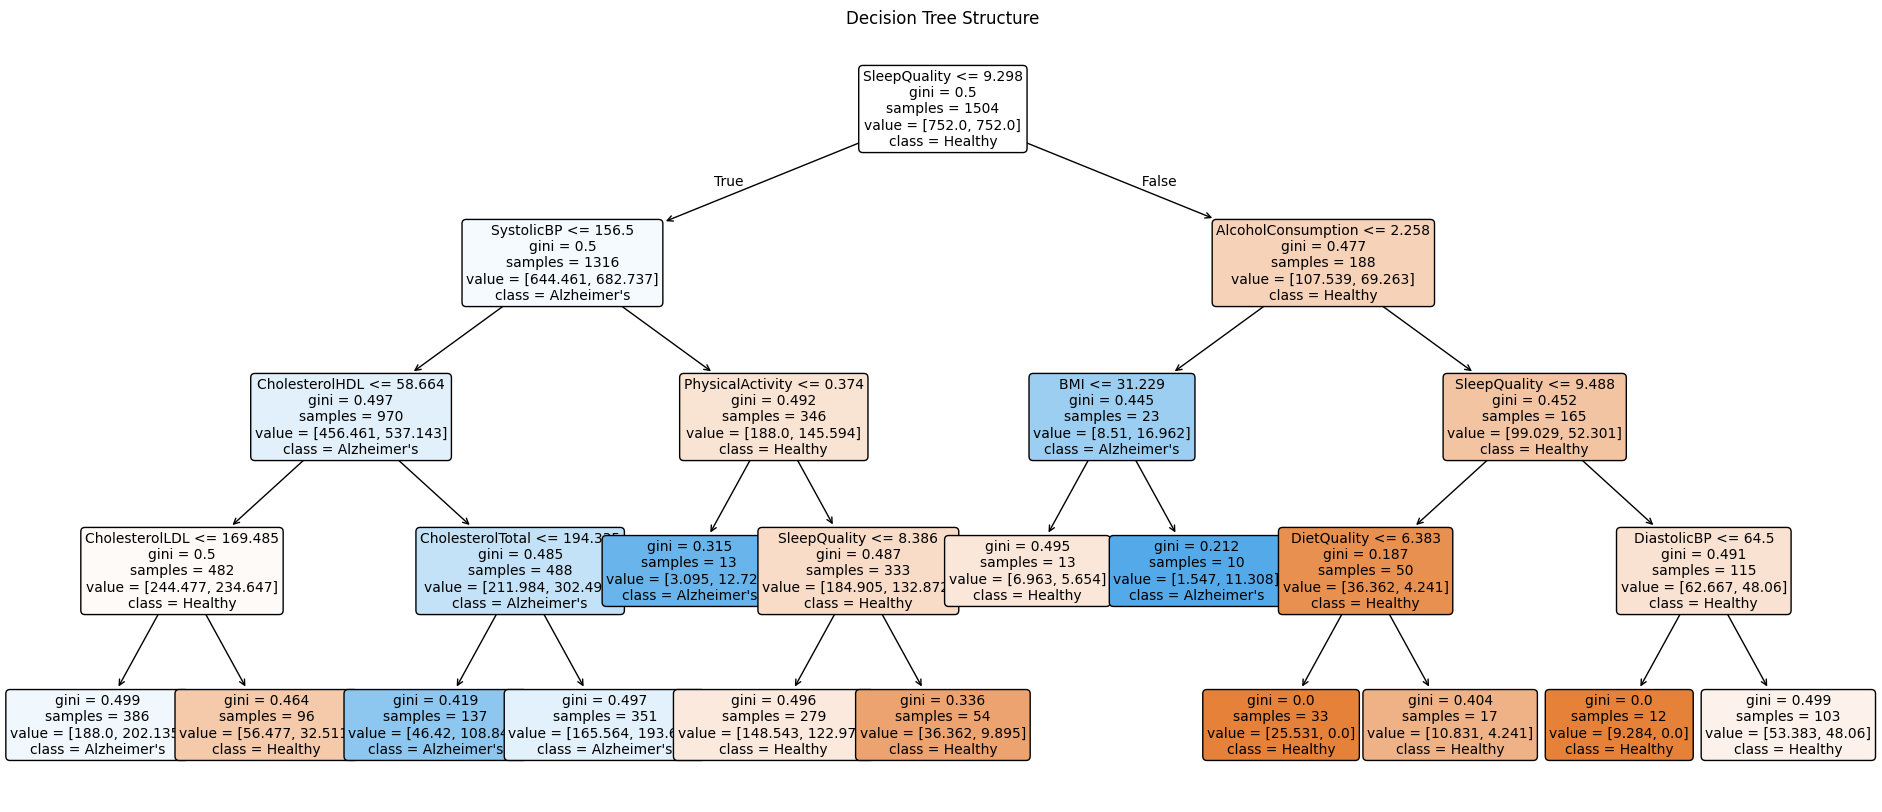

In [ ]:
# try only remove 5 variables that have very high correlation with the diagnosis
# result is still bad 

df_remove_6 = df.drop(columns=['MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL'], errors='ignore')
X = df_remove_6.drop(columns=["Diagnosis"])
y = df_remove_6["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y          # preserves 66/33 class ratio in both sets
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class dist:\n{y_train.value_counts(normalize=True).round(3)}")
# ── Step 5: Find best depth first ─────────────────────────────────────────
for depth in [2, 3, 4, 5, 8, None]:
    dt_temp = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=42)
    dt_temp.fit(X_train, y_train)
    y_proba_temp = dt_temp.predict_proba(X_test)[:, 1]
    print(f"depth={depth}  AUC={roc_auc_score(y_test, y_proba_temp):.3f}")

# ── Step 5b: Train final model with best depth ─────────────────────────────
# After running above, replace max_depth with whichever gave highest AUC
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,            # ← change this to best depth from loop above
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train, y_train)

# ── Step 6: Evaluate ───────────────────────────────────────────────────────
y_pred  = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Healthy", "Alzheimer's"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

# ── Step 7: Visualize ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# -- Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Healthy", "Alzheimer's"],
            yticklabels=["Healthy", "Alzheimer's"])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

# -- Feature Importances
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).tail(15).plot(
    kind="barh", ax=axes[1], color="steelblue"
)
axes[1].set_title("Top Feature Importances")
axes[1].set_xlabel("Gini Importance")

# -- ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[2],
                                  name=f"DT (AUC={roc_auc_score(y_test, y_proba):.2f})")
axes[2].set_title("ROC Curve")
axes[2].plot([0,1],[0,1],"k--")

plt.tight_layout()
plt.savefig("dt_evaluation.png", dpi=150)
plt.show()

# -- Tree Structure (separate figure — can get large)
plt.figure(figsize=(24, 10))
plot_tree(dt, feature_names=X.columns, class_names=["Healthy","Alzheimer's"],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure")
plt.savefig("dt_structure.png", dpi=150, bbox_inches="tight")
plt.show()


Train: (1504, 32), Test: (645, 32)
Train class dist:
Diagnosis
0    0.646
1    0.354
Name: proportion, dtype: float64
depth=2  AUC=0.828
depth=3  AUC=0.893
depth=4  AUC=0.917
depth=5  AUC=0.927
depth=8  AUC=0.894
depth=None  AUC=0.901

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.91      0.96      0.94       417
 Alzheimer's       0.93      0.83      0.88       228

    accuracy                           0.92       645
   macro avg       0.92      0.90      0.91       645
weighted avg       0.92      0.92      0.92       645

ROC-AUC: 0.924


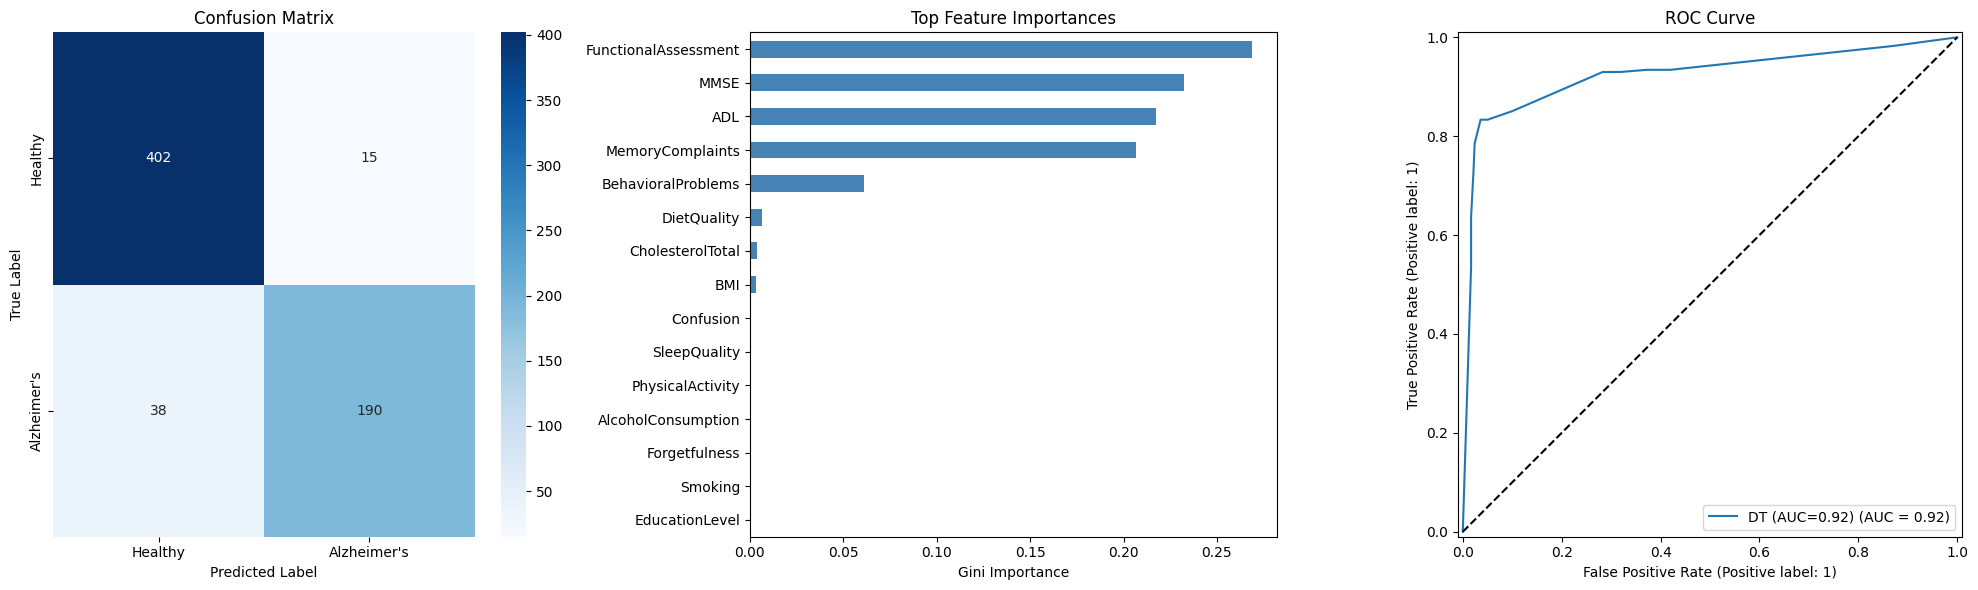

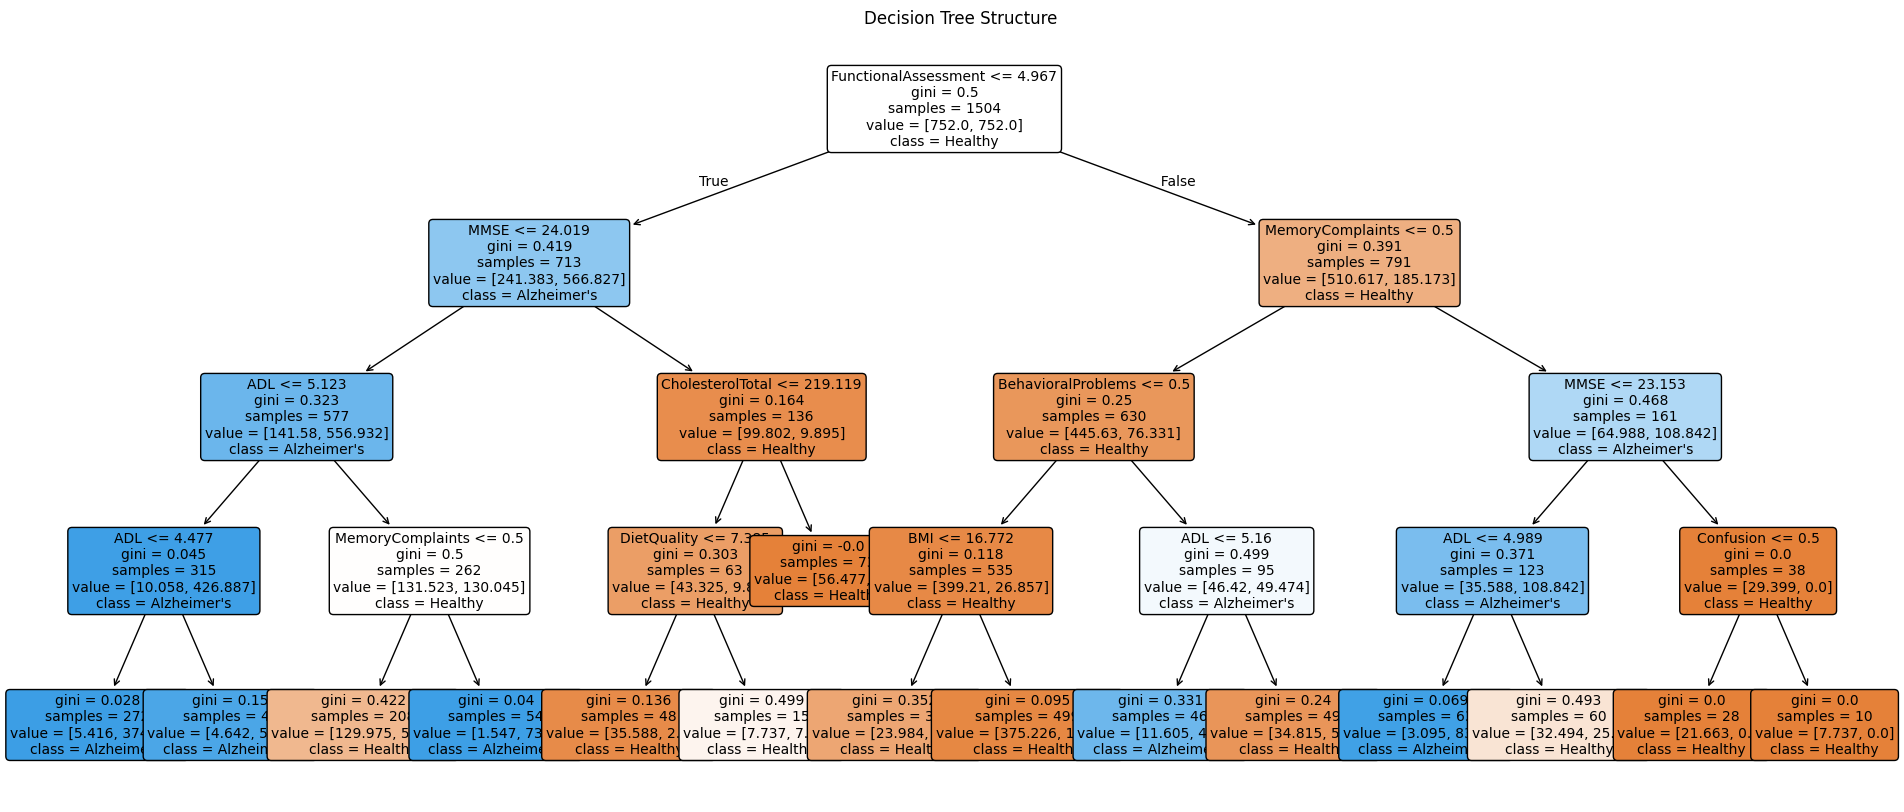

In [29]:
# try all variables 
# result is 

X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y          # preserves 66/33 class ratio in both sets
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class dist:\n{y_train.value_counts(normalize=True).round(3)}")
# ── Step 5: Find best depth first ─────────────────────────────────────────
for depth in [2, 3, 4, 5, 8, None]:
    dt_temp = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=42)
    dt_temp.fit(X_train, y_train)
    y_proba_temp = dt_temp.predict_proba(X_test)[:, 1]
    print(f"depth={depth}  AUC={roc_auc_score(y_test, y_proba_temp):.3f}")

# ── Step 5b: Train final model with best depth ─────────────────────────────
# After running above, replace max_depth with whichever gave highest AUC
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,            # ← change this to best depth from loop above
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train, y_train)

# ── Step 6: Evaluate ───────────────────────────────────────────────────────
y_pred  = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Healthy", "Alzheimer's"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

# ── Step 7: Visualize ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# -- Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Healthy", "Alzheimer's"],
            yticklabels=["Healthy", "Alzheimer's"])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

# -- Feature Importances
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).tail(15).plot(
    kind="barh", ax=axes[1], color="steelblue"
)
axes[1].set_title("Top Feature Importances")
axes[1].set_xlabel("Gini Importance")

# -- ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[2],
                                  name=f"DT (AUC={roc_auc_score(y_test, y_proba):.2f})")
axes[2].set_title("ROC Curve")
axes[2].plot([0,1],[0,1],"k--")

plt.tight_layout()
plt.savefig("dt_evaluation.png", dpi=150)
plt.show()

# -- Tree Structure (separate figure — can get large)
plt.figure(figsize=(24, 10))
plot_tree(dt, feature_names=X.columns, class_names=["Healthy","Alzheimer's"],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure")
plt.savefig("dt_structure.png", dpi=150, bbox_inches="tight")
plt.show()
